In [32]:
#导入所需库
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
#防止图片中文乱码
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
#读取主数据集信息
data=pd.read_csv('./$R74H62K/kiva_loans.csv')
data.head(10)
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671205 entries, 0 to 671204
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  671205 non-null  int64  
 1   funded_amount       671205 non-null  float64
 2   loan_amount         671205 non-null  float64
 3   activity            671205 non-null  object 
 4   sector              671205 non-null  object 
 5   use                 666973 non-null  object 
 6   country_code        671197 non-null  object 
 7   country             671205 non-null  object 
 8   region              614405 non-null  object 
 9   currency            671205 non-null  object 
 10  partner_id          657698 non-null  float64
 11  posted_time         671205 non-null  object 
 12  disbursed_time      668809 non-null  object 
 13  funded_time         622874 non-null  object 
 14  term_in_months      671205 non-null  float64
 15  lender_count        671205 non-nul

,id,funded_amount,loan_amount,partner_id,term_in_months,lender_count
count,6.712050e+05,671205.000000,671205.000000,657698.000000,671205.000000,671205.000000
mean,9.932486e+05,785.995061,842.397107,178.199616,13.739022,20.590922
std,1.966113e+05,1130.398941,1198.660073,94.247581,8.598919,28.459551
min,6.530470e+05,0.000000,25.000000,9.000000,1.000000,0.000000
25%,8.230720e+05,250.000000,275.000000,126.000000,8.000000,7.000000
50%,9.927800e+05,450.000000,500.000000,145.000000,13.000000,13.000000
75%,1.163653e+06,900.000000,1000.000000,204.000000,14.000000,24.000000
max,1.340339e+06,100000.000000,100000.000000,536.000000,158.000000,2986.000000


In [4]:
#检查数据集是否存在缺失值
data.isna().sum(axis=0)
data.dropna(inplace=True)

In [6]:
#查看数据集的前10行数据
#主要贷款的国家，行业
print(data['country'].value_counts().head(10))
print("-"*30)
print(data['sector'].value_counts().head(10))

country
Philippines    91317
Kenya          47261
Cambodia       25787
Pakistan       20681
Tajikistan     15556
Colombia       14683
Peru           14232
El Salvador    13753
Uganda         12932
Ecuador        10153
Name: count, dtype: int64
------------------------------
sector
Agriculture       117496
Food               80786
Retail             71671
Services           29314
Personal Use       26185
Education          24169
Housing            20578
Clothing           20322
Transportation      9477
Arts                7888
Name: count, dtype: int64


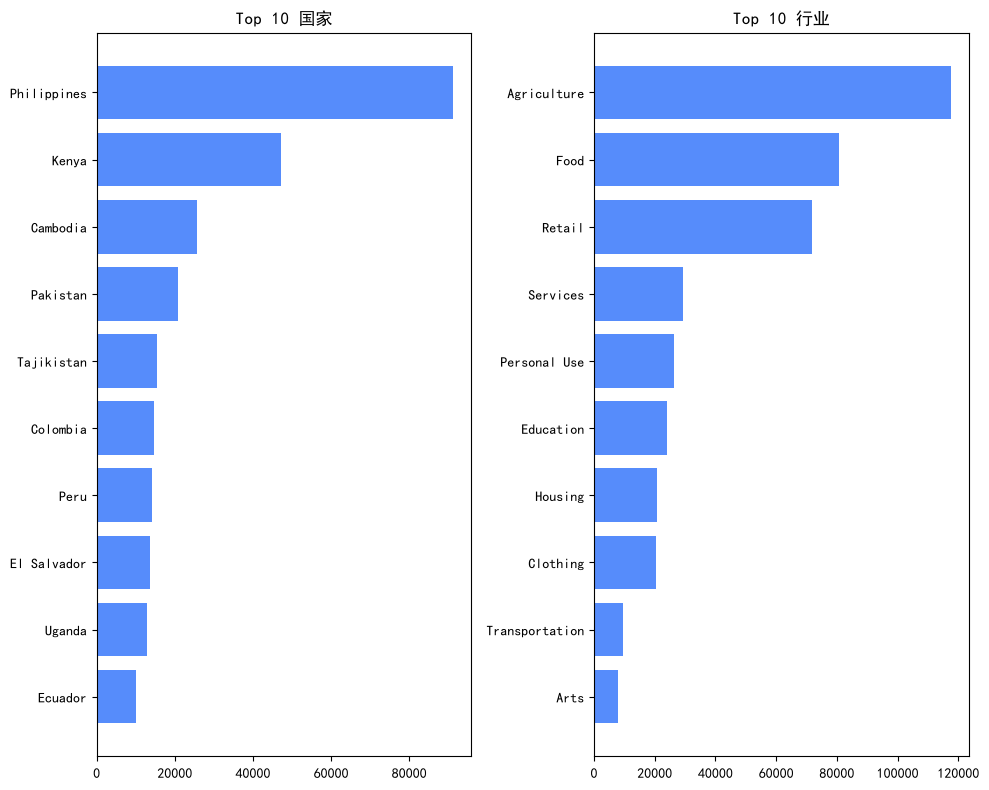

In [12]:
plt.figure(figsize=(10,8))
f1=plt.subplot(121)
f2=plt.subplot(122)
country = data['country'].value_counts().sort_values(ascending=False).head(10)
sector  = data['sector'].value_counts().sort_values(ascending=False).head(10)

f1.barh(country.index[::-1], country.values[::-1])
f2.barh(sector.index[::-1], sector.values[::-1])
f1.set_title("Top 10 国家")
f2.set_title("Top 10 行业")
plt.tight_layout()
plt.show()


In [13]:
country = data['country'].value_counts().head(10)
print(country)
print("第一名占比：", country.iloc[0] / data.shape[0])
print("由此可知,菲律宾是贷款的绝对主力")

country
Philippines    91317
Kenya          47261
Cambodia       25787
Pakistan       20681
Tajikistan     15556
Colombia       14683
Peru           14232
El Salvador    13753
Uganda         12932
Ecuador        10153
Name: count, dtype: int64
第一名占比： 0.21583810192374508
由此可知,菲律宾是贷款的绝对主力


In [24]:
sector = data['sector'].value_counts()
print(sector)
print("前 3 行业占比：", sector.head(3).sum() / data.shape[0])
print(f"{','.join(sector.head(3).index)}三个行业占据绝对主力")

sector
Agriculture       117496
Food               80786
Retail             71671
Services           29314
Personal Use       26185
Education          24169
Housing            20578
Clothing           20322
Transportation      9477
Arts                7888
Health              6484
Construction        3976
Manufacturing       3810
Entertainment        466
Wholesale            459
Name: count, dtype: int64
前 3 行业占比： 0.6380645786504239
Agriculture,Food,Retail三个行业占据绝对主力


In [28]:
top=data.groupby(['country','sector']).size().sort_values(ascending=False).head(10)
print(f"交叉验证发现，{'的'.join(top.index[0])}是贷款主力")

交叉验证发现，Philippines的Retail是贷款主力


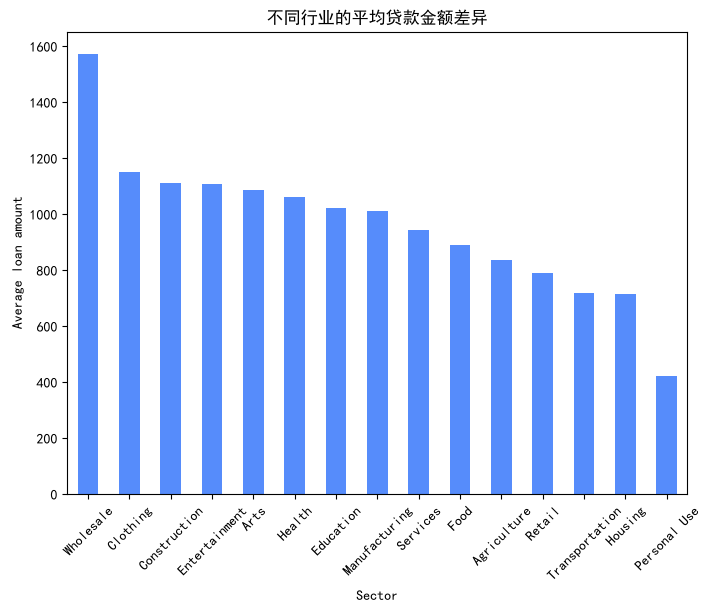

由图发现'Wholesale'行业的平均贷款金额最高


In [84]:
#不同行业贷款分析
sec=data.groupby('sector')['loan_amount'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,6))
sec.plot(kind='bar')
plt.title("不同行业的平均贷款金额差异")
plt.xlabel("Sector")
plt.ylabel("Average loan amount")
plt.xticks(rotation=45)
plt.show()
print(f"由图发现'{sec.index[0]}'行业的平均贷款金额最高")

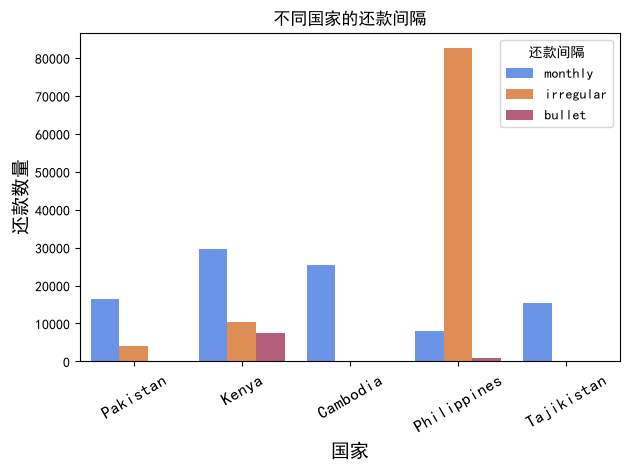

In [40]:
top5 = data['country'].value_counts().head(5).index
sub = data[data['country'].isin(top5)]

import seaborn as sns
sns.countplot(data=sub, x='country', hue='repayment_interval')
plt.title('不同国家的还款间隔')
plt.xticks(rotation=30,fontsize=12)
plt.legend(title='还款间隔')
plt.xlabel("国家",fontsize=14)
plt.ylabel("数量",fontsize=14)

plt.tight_layout()
plt.show()

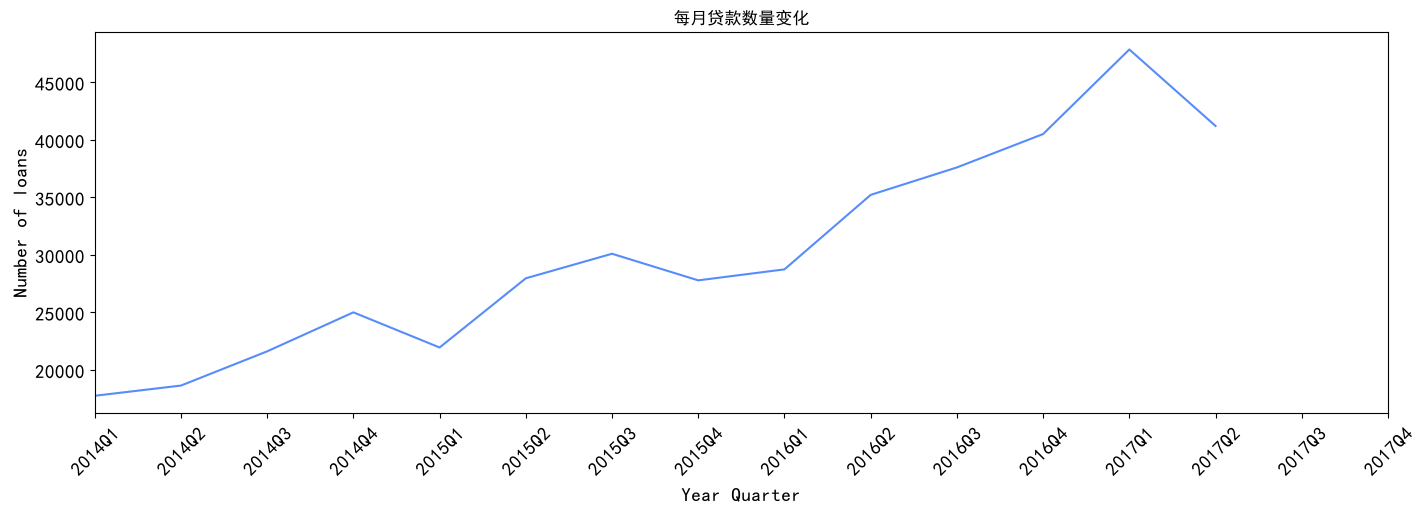

In [50]:
data['date'] = pd.to_datetime(data['date'])
data['year_month'] = data['date'].dt.to_period('Q')

quarterly = data.groupby('year_month').size()
quarterly = quarterly.iloc[0:14]
plt.figure(figsize=(14, 5))
quarterly.plot()
plt.xlabel("Year Quarter",fontsize=14)
plt.title("每季度贷款数量变化")
plt.ylabel("Number of loans",fontsize=14)
plt.tight_layout()
plt.xticks([f'{y}Q{q}' for y in range(2014, 2018) for q in range(1, 5)],
           [f'{y}Q{q}' for y in range(2014, 2018) for q in range(1, 5)],
           rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.show()

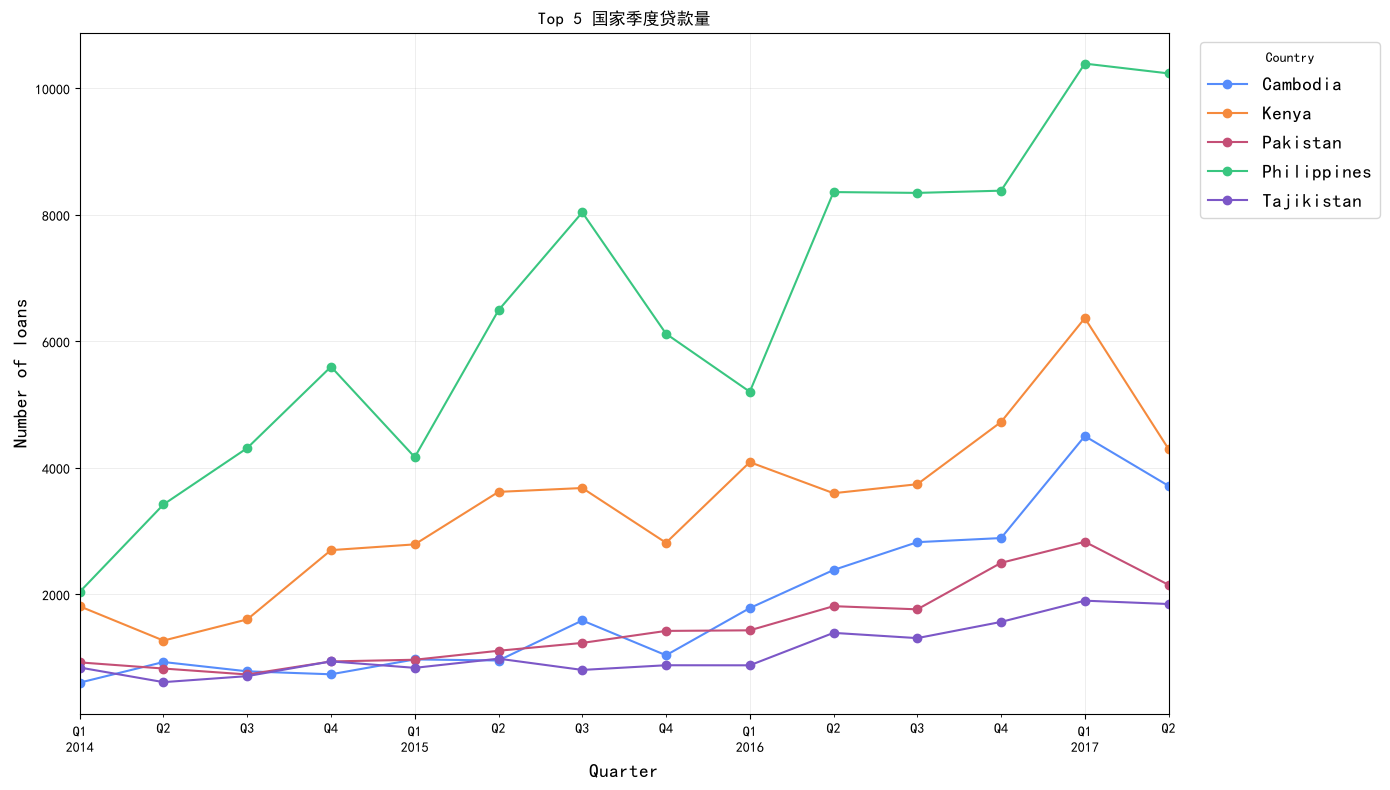

整体来看，Philippines的贷款数量最多,峰值在2017Q1，数量为10393
------------------------------
各国峰值季度:
country
Cambodia       2017Q1
Kenya          2017Q1
Pakistan       2017Q1
Philippines    2017Q1
Tajikistan     2017Q1
dtype: period[Q-DEC]
------------------------------

整体增长率:
country
Cambodia       5.13%
Philippines    4.02%
Kenya          1.37%
Pakistan       1.32%
Tajikistan     1.19%
dtype: object
------------------------------

各个国家在贷款总量中的占比:
country
Philippines    45.53%
Kenya          23.55%
Cambodia       12.85%
Pakistan       10.32%
Tajikistan      7.75%
dtype: object


In [83]:
#时间*国家

#数据处理
data['date']=pd.to_datetime(data['date'])
data['quarter']=data['date'].dt.to_period('Q')
top5=data['country'].value_counts().head(5).index
sub=data[data['country'].isin(top5)]

#准备作图
pivot=sub.groupby(['quarter','country']).size().unstack().fillna(0)
pivot=pivot.iloc[:-1]

#作图
plt.figure(figsize=(14,8))
pivot.plot(ax=plt.gca(),marker='o')
plt.title("Top 5 国家季度贷款量")
plt.xlabel("Quarter",fontsize=14)
plt.ylabel("Number of loans",fontsize=14)
plt.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#总结
print(f'整体来看，{pivot.sum(axis=0).idxmax()}的贷款数量最多,峰值在{pivot.idxmax(axis=0).max()}，数量为{pivot.max().max()}')
print("-"*30)
#各国峰值
peak = pivot.idxmax(axis=0)
print("各国峰值季度:")
print(peak)
print("-"*30)
#每个国家的"整体增长率"（首季 vs 末季）
growth = pivot.iloc[-1] / pivot.iloc[0] - 1
print("\n整体增长率:")
print(growth.sort_values(ascending=False).map(lambda x: f'{x:.2f}%'))
print("-"*30)
#各个国家在贷款总量中的占比
country_share = pivot.sum() / pivot.sum().sum()
print("\n各个国家在贷款总量中的占比:")
print(country_share.sort_values(ascending=False).map(lambda x: f'{x:.2%}'))

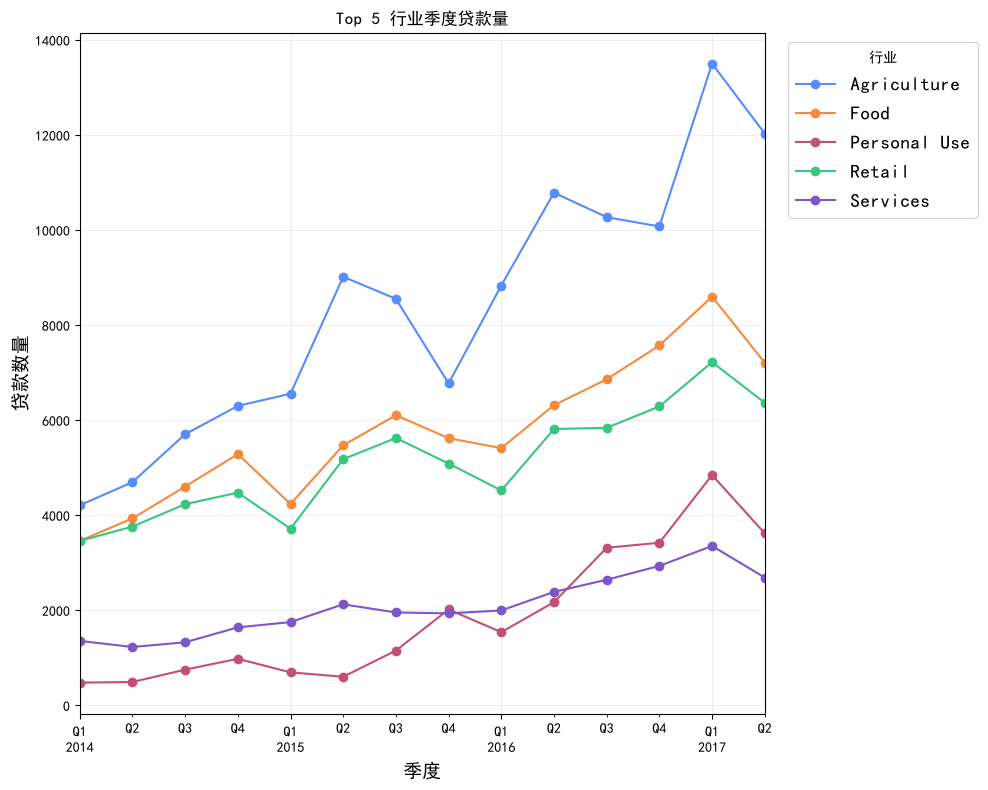


各行业总贷款量:
sector
Agriculture     117253
Food             80633
Retail           71530
Services         29268
Personal Use     26023
dtype: int64
------------------------------
各行业贷款峰值季度
sector
Agriculture     2017Q1
Food            2017Q1
Personal Use    2017Q1
Retail          2017Q1
Services        2017Q1
dtype: period[Q-DEC]


In [101]:
#行业*季度
#数据处理
top5=data['sector'].value_counts().head(5).index
sub=data[data['sector'].isin(top5)]

#准备作图
pivot=sub.groupby(['quarter','sector']).size().unstack().fillna(0)
pivot=pivot.iloc[:-1]
#作图
plt.figure(figsize=(10,8))
pivot.plot(ax=plt.gca(),marker='o')
plt.title("Top 5 行业季度贷款量")
plt.xlabel("季度",fontsize=14)
plt.ylabel("贷款数量",fontsize=14)
plt.legend(title='行业', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#总结
print("\n各行业总贷款量:")
print(pivot.sum().sort_values(ascending=False))
print("-"*30)
print('各行业贷款峰值季度')
print(pivot.idxmax())


In [129]:
#报告
#1.数据概览
print("=" * 50)
print("Kiva 小额信贷数据分析 —— 报告摘要")
print("=" * 50)
print(f"记录数：{len(data):,}")
print(f"覆盖国家：{data['country'].nunique()}")
print(f"覆盖行业：{data['sector'].nunique()}")
print(f"时间跨度：{data['date'].min().date()} ~ {data['date'].max().date()}")
print(f"数据集包含{len(data):,}条记录，覆盖了{data['country'].nunique()}个国家和{data['sector'].nunique()}个行业，时间跨度为{data['date'].min().date()} ~ {data['date'].max().date()}。")

print("-"*30)
#国家维度*行业维度
top5_countries=data['country'].value_counts().head(5).index
top5_sectors=data['sector'].value_counts().head(5).index

print(f"从国家维度看,kiva贷款高度集中于{','.join(top5_countries)}五个国家，其中{top5_countries[0]}常年领跑，占比为{data['country'].value_counts().head(1).sum()/data.shape[0]:.2%}。")
print(f'top5国家占据份额：{data["country"].value_counts().head(5).sum()/data.shape[0]:.2%}')
print(f"→ 解读：国家集中度较高，菲律宾是绝对主力，说明 Kiva 业务布局有明显的地域重心。")
print("-"*30)
print(f"从行业维度看,kiva贷款高度集中于{','.join(top5_sectors)}五个行业，其中{top5_sectors[0]}常年领跑，占比为{data['sector'].value_counts().head(1).sum()/data.shape[0]:.2%}。")
print(f'top5行业占据份额：{data["sector"].value_counts().head(5).sum()/data.shape[0]:.2%}')
print(f"→ 解读：行业集中度极高，前 5 大行业占据近八成贷款，"
      f"说明 Kiva 的资金主要支持农业和生活类小生意。")
print("-"*30)

#3.时间维度
# --- 时间维度 ---
q = data.groupby('quarter').size()
q_clean = q.iloc[1:-1]
growth = q_clean.iloc[-1] / q_clean.iloc[0]
cv = q_clean.std() / q_clean.mean()
mom = q_clean.pct_change()

print(f"\n【四、时间维度】")
print(f"时间区间：{q_clean.index[0]} ~ {q_clean.index[-1]}")
print(f"首季 {q_clean.iloc[0]:,} 笔 → 末季 {q_clean.iloc[-1]:,} 笔，增长 {growth:.1f} 倍。")
print(f"峰值 {q_clean.idxmax()}（{q_clean.max():,} 笔），"
      f"低谷 {q_clean.idxmin()}（{q_clean.min():,} 笔）。")
print(f"波动系数 {cv:.1%}，"
      f"{'波动较大' if cv > 0.5 else '增长相对平稳'}。")
print(f"环比增长最快：{mom.idxmax()}（+{mom.max():.1%}）")
print(f"环比下跌最快：{mom.idxmin()}（{mom.min():.1%}）")
print(f"→ 解读：Kiva 在 3.5 年内季度贷款量翻了 2 倍以上，处于快速扩张期，"
      f"整体呈持续上升趋势。")

Kiva 小额信贷数据分析 —— 报告摘要
记录数：423,081
覆盖国家：81
覆盖行业：15
时间跨度：2014-01-01 ~ 2017-07-14
数据集包含423,081条记录，覆盖了81个国家和15个行业，时间跨度为2014-01-01 ~ 2017-07-14。
------------------------------
从国家维度看,kiva贷款高度集中于Philippines,Kenya,Cambodia,Pakistan,Tajikistan五个国家，其中Philippines常年领跑，占比为21.58%。
top5国家占据份额：47.41%
→ 解读：国家集中度较高，菲律宾是绝对主力，说明 Kiva 业务布局有明显的地域重心。
------------------------------
从行业维度看,kiva贷款高度集中于Agriculture,Food,Retail,Services,Personal Use五个行业，其中Agriculture常年领跑，占比为27.77%。
top5行业占据份额：76.92%
→ 解读：行业集中度极高，前 5 大行业占据近八成贷款，说明 Kiva 的资金主要支持农业和生活类小生意。
------------------------------

【四、时间维度】
时间区间：2014Q2 ~ 2017Q2
首季 18,646 笔 → 末季 41,217 笔，增长 2.2 倍。
峰值 2017Q1（47,868 笔），低谷 2014Q2（18,646 笔）。
波动系数 28.2%，增长相对平稳。
环比增长最快：2015Q2（+27.4%）
环比下跌最快：2017Q2（-13.9%）
→ 解读：Kiva 在 3.5 年内季度贷款量翻了 2 倍以上，处于快速扩张期，整体呈持续上升趋势。


In [130]:
print("\n【五、总结与建议】")
print("1. 国家高度集中：Top 5 国家占 47.41%，其中菲律宾占 21.58%，"
      "属于核心市场，应重点维护。")
print("2. 行业高度集中：Top 5 行业占 76.92%，"
      "农业（27.77%）是绝对主力，说明 Kiva 的核心价值是支持农业小生意。")
print("3. 时间持续增长：季度贷款量从 1.7 万增长到 4.1 万，3.5 年增长 2.3 倍，"
      "平台处于高速扩张期。")
print("4. 数据建议：时间跨度为 2014-01 ~ 2017-07，"
      "如需最新趋势需补充 2017 年之后的数据。")


【五、总结与建议】
1. 国家高度集中：Top 5 国家占 47.41%，其中菲律宾占 21.58%，属于核心市场，应重点维护。
2. 行业高度集中：Top 5 行业占 76.92%，农业（27.77%）是绝对主力，说明 Kiva 的核心价值是支持农业小生意。
3. 时间持续增长：季度贷款量从 1.7 万增长到 4.1 万，3.5 年增长 2.3 倍，平台处于高速扩张期。
4. 数据建议：时间跨度为 2014-01 ~ 2017-07，如需最新趋势需补充 2017 年之后的数据。
